# Published MIS 6 speleothem records

This notebook displays four published proxy records, their literature event labels and local sampling intervals, followed by a focused Sofular–MF comparison. Labels are approximate plotting anchors; this notebook does not estimate event ages or synchronize chronologies.

Run the cells in order with `MIS6/` as the working directory. Inputs are the proxy workbook, the published-label table and the visually assessed Sofular–MF match table. Ages are already in kyr BP relative to AD 1950. All time axes place older ages on the left and younger ages on the right; the underlying age coordinates are unchanged.

The workbook combines records from several studies: MF is from [Fohlmeister et al. (2023)](https://doi.org/10.1038/s43247-023-00908-0) and Sofular is from [Held et al. (2024)](https://doi.org/10.1038/s41467-024-45507-5). The supporting Sanbao and Huagapo records retain their source citations in the worksheet names and anchor table.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

# Run from MIS6; only the paper exporter is imported from the project root.
sys.path.insert(0, str(Path("..").resolve()))
from paper_figure_export import copy_pdf_to_paper
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
from matplotlib.ticker import FuncFormatter, LogLocator, MaxNLocator, MultipleLocator, NullFormatter
from scipy.ndimage import gaussian_filter1d

workbook = Path("data/raw/MIS6_speleothem_records.xlsx")
anchor_path = Path("data/curated/speleothem_mis6_published_event_label_anchors.csv")
match_path = Path("data/curated/Sofular_MF_visual_peak_match.csv")
figure_dir = Path("figures/Speleothem_published_event_plot")
age_range = (125.0, 205.0)
comparison_range = (158.0, 205.0)
gap_threshold = 0.5  # kyr; larger sampling gaps split both raw and smoothed curves.
grid_step = 0.001   # kyr; interpolation grid, not the original data resolution.

# MF's worksheet name starts with a BOM character in the source workbook.
specs = {
    "Sanbao": dict(sheet="Sanbao_Wang_etal_2008", proxy=r"$\delta^{18}\mathrm{O}$ (‰ VPDB)",
                   color="#007C91", invert=True, sigma=0.100,
                   title="Sanbao · events identified in Held et al. (2024)"),
    "Huagapo": dict(sheet="Huagapo_Burn_etal_2019", proxy=r"$\delta^{18}\mathrm{O}$ (‰ VPDB)",
                    color="#1976D2", invert=False, sigma=0.100,
                    title="Huagapo · events identified in Held et al. (2024)"),
    "Sofular": dict(sheet="Sofular_Held_etal_2024", proxy=r"$\delta^{13}\mathrm{C}$ (‰ VPDB)",
                    color="#6A1B9A", invert=True, sigma=0.050,
                    title="Sofular · events identified in Held et al. (2024)"),
    "MF": dict(sheet="\ufeffMF_Fohlmeister_etal_2023", proxy=r"$\delta^{18}\mathrm{O}$ (‰ VPDB)",
               color="#C43C39", invert=False, sigma=0.050,
               title="Melchsee-Frutt (MF) · events identified in Fohlmeister et al. (2023)"),
}
plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans", "font.size": 8, "axes.labelsize": 8.5,
    "axes.titlesize": 8.5, "axes.titleweight": "semibold", "axes.edgecolor": "#4B4B4B",
    "axes.linewidth": 0.7, "xtick.labelsize": 7.5, "ytick.labelsize": 7.5,
    "xtick.color": "#333333", "ytick.color": "#333333",
    "xtick.direction": "out", "ytick.direction": "out",
    "pdf.fonttype": 42, "ps.fonttype": 42, "savefig.facecolor": "white",
})

## Read and prepare the records

The first two worksheet columns contain age and proxy values. Non-numeric or missing pairs are removed, duplicate ages are averaged and ages are sorted. Local resolution is the median of the two adjacent sampling intervals; endpoints use their single adjacent interval.

Each continuous segment is interpolated to a 1-year grid before Gaussian smoothing (σ = 100 years for Sanbao and Huagapo; 50 years for Sofular and MF). Neither interpolation nor smoothing crosses a gap greater than 0.5 kyr. The full records are retained: display limits do not change the resolution summaries or smoothing domain.

In [2]:
def smooth_record_segments(ages, proxy, sigma_ka):
    """Interpolate and smooth within continuous segments, without bridging gaps."""
    boundaries = np.r_[0, np.flatnonzero(np.diff(ages) > gap_threshold) + 1, len(ages)]
    segments = []
    for start, stop in zip(boundaries[:-1], boundaries[1:]):
        x, y = ages[start:stop], proxy[start:stop]
        if len(x) < 2:
            continue
        grid = np.arange(x[0], x[-1] + grid_step / 2, grid_step)
        curve = gaussian_filter1d(np.interp(grid, x, y), sigma_ka / grid_step, mode="nearest")
        segments.append((grid, curve))
    return segments

anchors = pd.read_csv(anchor_path, dtype={
    "record_id": "string", "sheet_name": "string", "event_label": "string", "display_label": "string",
})
anchors["anchor_age_ka_bp"] = pd.to_numeric(anchors["anchor_age_ka_bp"], errors="raise")
assert anchors["anchor_age_ka_bp"].notna().all()
assert anchors["anchor_purpose"].eq("label_placement_only").all()
assert not anchors.duplicated(["record_id", "event_label"]).any()
assert set(anchors["record_id"]) == set(specs)
matches = pd.read_csv(match_path).apply(pd.to_numeric, errors="raise")
assert matches.columns.tolist() == ["Sofular", "MF"]
assert matches.notna().all().all() and not matches.duplicated().any()
assert matches.apply(lambda col: col.between(*comparison_range).all()).all()
matches = matches.sort_values("Sofular").reset_index(drop=True)

records, smoothed, record_anchors = {}, {}, {}
for name, spec in specs.items():
    frame = pd.read_excel(workbook, sheet_name=spec["sheet"]).iloc[:, :2].copy()
    frame.columns = ["age_ka_bp", "proxy"]
    frame = frame.apply(pd.to_numeric, errors="coerce").dropna()
    frame = frame.groupby("age_ka_bp", as_index=False)["proxy"].mean().sort_values("age_ka_bp").reset_index(drop=True)
    age = frame["age_ka_bp"].to_numpy()
    gaps = np.diff(age)
    assert len(frame) >= 2 and np.all(gaps > 0), name
    # Convert sampling intervals from kyr to years; they are not age uncertainties.
    resolution = np.r_[gaps[0], np.median(np.vstack([gaps[:-1], gaps[1:]]), axis=0), gaps[-1]]
    frame["resolution_yr"] = resolution * 1000
    local = anchors.loc[anchors["record_id"].eq(name)].sort_values("anchor_age_ka_bp").reset_index(drop=True)
    assert set(local["sheet_name"]) == {spec["sheet"]}, name
    assert local["anchor_age_ka_bp"].between(age.min(), age.max()).all(), name
    assert np.ptp(frame["proxy"]) > 0, name
    records[name], record_anchors[name] = frame, local
    smoothed[name] = smooth_record_segments(age, frame["proxy"].to_numpy(), spec["sigma"])

pd.DataFrame({name: {"samples": len(frame), "labels": len(record_anchors[name]),
                    "youngest_kyr_bp": frame.age_ka_bp.min(), "oldest_kyr_bp": frame.age_ka_bp.max(),
                    "median_resolution_yr": frame.resolution_yr.median()}
              for name, frame in records.items()}).T

,samples,labels,youngest_kyr_bp,oldest_kyr_bp,median_resolution_yr
Sanbao,728.0,13.0,128.700000,204.900000,100.0000
Huagapo,1166.0,12.0,135.646951,196.583806,53.1317
Sofular,1653.0,8.0,160.863000,204.784000,20.0000
MF,4077.0,16.0,132.411000,202.206000,5.6500


## Small plotting helpers

Both figures use the same prepared curves. Nearby labels are shifted only for readability; connectors retain the original anchor positions. Raw curves are also broken at the same data gaps used for smoothing.

In [3]:
def spread_label_positions(ages):
    """Move the outer labels of close clusters, leaving anchor ages unchanged."""
    positions = ages.astype(float, copy=True)
    for i, age in enumerate(ages):
        previous_close = i > 0 and age - ages[i - 1] < 1.3
        next_close = i + 1 < len(ages) and ages[i + 1] - age < 1.3
        if next_close and not previous_close:
            positions[i] -= 0.45
        elif previous_close and not next_close:
            positions[i] += 0.45
    return positions


def draw_curves(axis, name, **raw_style):
    """Draw gap-separated raw segments and their prepared smoothed curves."""
    frame, color = records[name], specs[name]["color"]
    ages, proxy = frame.age_ka_bp.to_numpy(), frame.proxy.to_numpy()
    boundaries = np.r_[0, np.flatnonzero(np.diff(ages) > gap_threshold) + 1, len(ages)]
    for start, stop in zip(boundaries[:-1], boundaries[1:]):
        axis.plot(ages[start:stop], proxy[start:stop], zorder=1, **raw_style)
    for x, y in smoothed[name]:
        axis.plot(x, y, color=color, lw=1.45, solid_capstyle="round", zorder=2)


def style_axis(axis):
    axis.set_axisbelow(True)
    axis.spines[["top", "right"]].set_visible(False)
    axis.tick_params(length=3, width=0.65)

## Four-record overview

Each record has a proxy panel and a logarithmic sampling-resolution panel over 125–205 kyr BP. Gray curves show the cleaned original data and colored curves show Gaussian smoothing. Pale bands hold the published labels; shaded intervals mark data gaps. Sanbao and Sofular proxy axes are reversed to match the comparison convention.

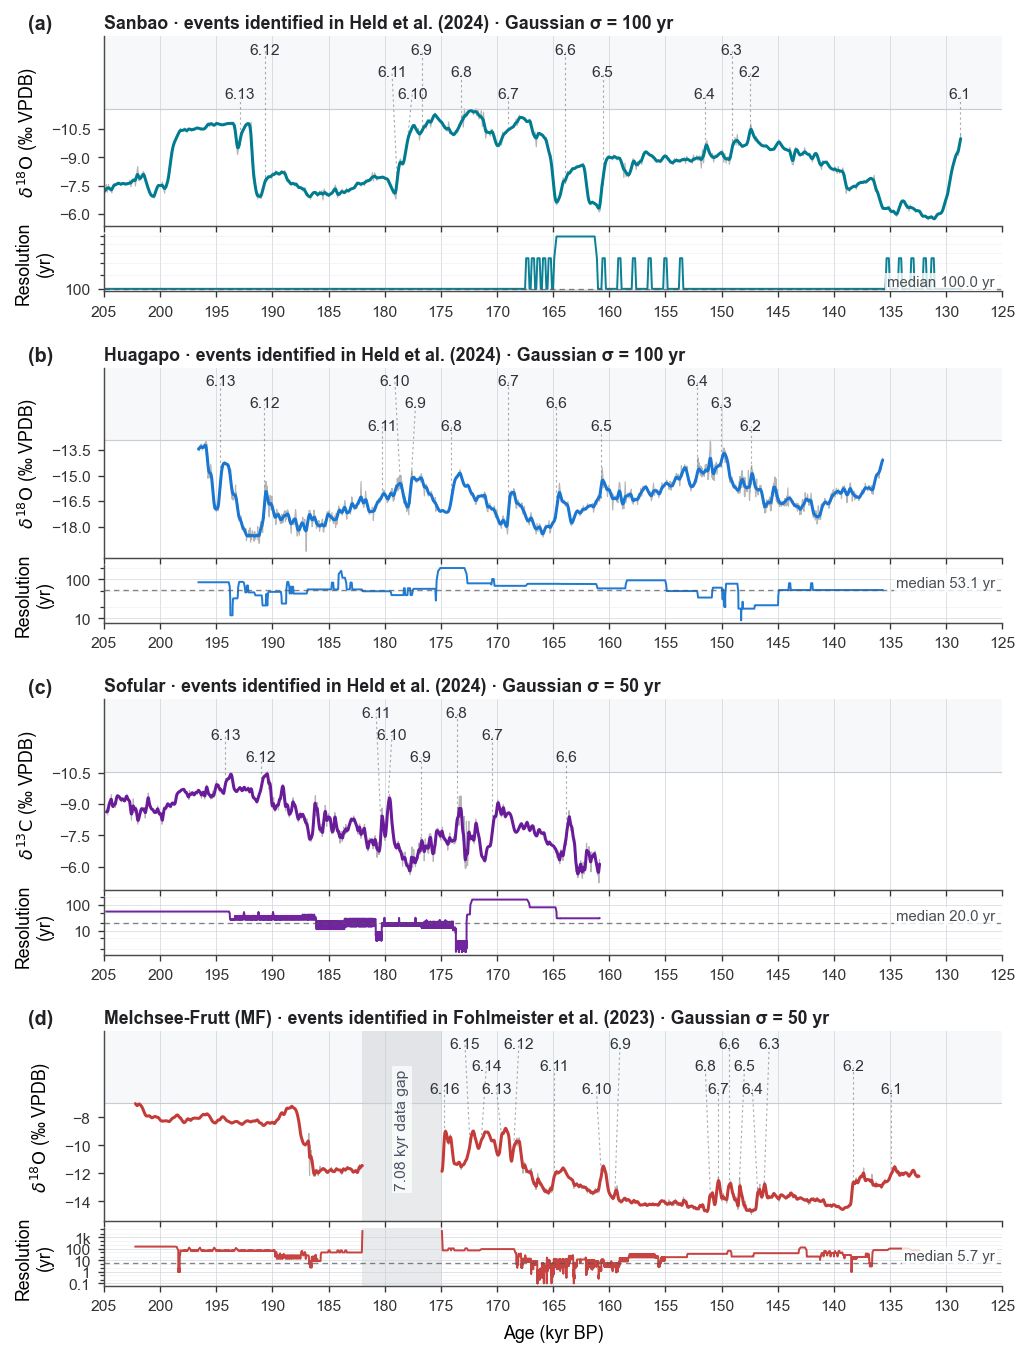

In [4]:
fig_overview = plt.figure(figsize=(180 / 25.4, 230 / 25.4), facecolor="white")
outer = fig_overview.add_gridspec(4, 1, left=0.14, right=0.985, top=0.975, bottom=0.055, hspace=0.30)
shared_axis = None
for row, (name, spec) in enumerate(specs.items()):
    pair = outer[row].subgridspec(2, 1, height_ratios=(3.3, 1), hspace=0.06)
    ax = fig_overview.add_subplot(pair[0], sharex=shared_axis)
    if shared_axis is None:
        shared_axis = ax
    res_ax = fig_overview.add_subplot(pair[1], sharex=shared_axis)
    frame, local = records[name], record_anchors[name]
    age, proxy, resolution = frame.age_ka_bp.to_numpy(), frame.proxy.to_numpy(), frame.resolution_yr.to_numpy()
    for axis in (ax, res_ax):
        style_axis(axis)
        # BP ages decrease toward the right, consistently across shared axes.
        axis.set_xlim(age_range[1], age_range[0])
        axis.xaxis.set_major_locator(MultipleLocator(5))
        axis.grid(axis="x", which="major", color="#CBD0D6", lw=0.45, alpha=0.7)
    draw_curves(ax, name, color="#B5B5B5", lw=0.55, solid_capstyle="round")
    low, high = proxy.min(), proxy.max()
    span = high - low
    edge = low - 0.65 * span if spec["invert"] else high + 0.65 * span
    boundary = low if spec["invert"] else high
    ax.axhspan(min(edge, boundary), max(edge, boundary), color="#F7F8FA", lw=0, zorder=0)
    ax.axhline(boundary, color="#C9CDD2", lw=0.55, zorder=1)
    ax.set_ylim((high + 0.06 * span, edge) if spec["invert"] else (low - 0.06 * span, edge))
    ticks = MaxNLocator(nbins=5).tick_values(low, high)
    ax.set_yticks(ticks[(ticks >= low) & (ticks <= high)])
    ax.set_ylabel(spec["proxy"], labelpad=5)
    ax.set_title(f'{spec["title"]} · Gaussian σ = {spec["sigma"] * 1000:.0f} yr', loc="left", pad=4, color="#202124")
    ax.text(-0.085, 1.015, f'({"abcd"[row]})', transform=ax.transAxes, ha="left", va="bottom",
            fontsize=9.5, fontweight="bold", color="#202124", clip_on=False)
    label_ages = spread_label_positions(local.anchor_age_ka_bp.to_numpy())
    for i, event in local.iterrows():
        x = event.anchor_age_ka_bp
        offset = (0.13, 0.33, 0.53)[i % 3] * span
        label_y = low - offset if spec["invert"] else high + offset
        ax.plot([x, label_ages[i]], [np.interp(x, age, proxy), label_y],
                color="#6F757B", lw=0.55, ls=(0, (2, 2.5)), alpha=0.6, zorder=1.5)
        ax.text(label_ages[i], label_y, event.display_label, ha="center", va="center",
                fontsize=7.5, color="#30343B", clip_on=True, zorder=4)

    boundaries = np.r_[0, np.flatnonzero(np.diff(age) > gap_threshold) + 1, len(age)]
    for start, stop in zip(boundaries[:-1], boundaries[1:]):
        res_ax.plot(age[start:stop], resolution[start:stop], color=spec["color"], lw=0.95, alpha=0.96, zorder=2)
    res_ax.set_yscale("log")
    res_ax.set_ylabel("Resolution\n(yr)", labelpad=5)
    res_ax.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
    res_ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1000:g}k" if value >= 1000 else f"{value:g}"))
    res_ax.yaxis.set_minor_locator(LogLocator(base=10, subs=(2, 5), numticks=12))
    res_ax.yaxis.set_minor_formatter(NullFormatter())
    res_ax.grid(axis="y", which="major", color="#D0D5DB", lw=0.45, alpha=0.7)
    res_ax.grid(axis="y", which="minor", color="#E5E7EB", lw=0.35, alpha=0.55)
    median = np.median(resolution)
    res_ax.axhline(median, color="#50555A", lw=0.65, ls=(0, (4, 3)), alpha=0.72, zorder=3)
    res_ax.text(age_range[0] + 0.65, median, f"median {median:.1f} yr", ha="right", va="bottom", fontsize=7.2,
                color="#4B5055", bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1), zorder=5)
    for i in np.flatnonzero(np.diff(age) > gap_threshold):
        start, end = age[i:i + 2]
        for axis in (ax, res_ax):
            axis.axvspan(start, end, color="#6B7280", alpha=0.15, lw=0, zorder=0)
        ax.text((start + end) / 2, 0.48, f"{end - start:.2f} kyr data gap", transform=ax.get_xaxis_transform(),
                rotation=90, ha="center", va="center", fontsize=7.5, color="#4B5563",
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.72, pad=1.4), zorder=6)
    ax.tick_params(axis="x", labelbottom=False)
    res_ax.tick_params(axis="x", labelbottom=True)
res_ax.set_xlabel("Age (kyr BP)", labelpad=5)
plt.show()

## Sofular–MF comparison

The focused figure covers 158–205 kyr BP. Sofular labels sit above its curve and MF labels below, leaving space between the panels for the six visually assessed matches. Connecting lines use the two ages supplied in the match table; they do not alter either chronology. Proxy limits still reflect the full loaded records.

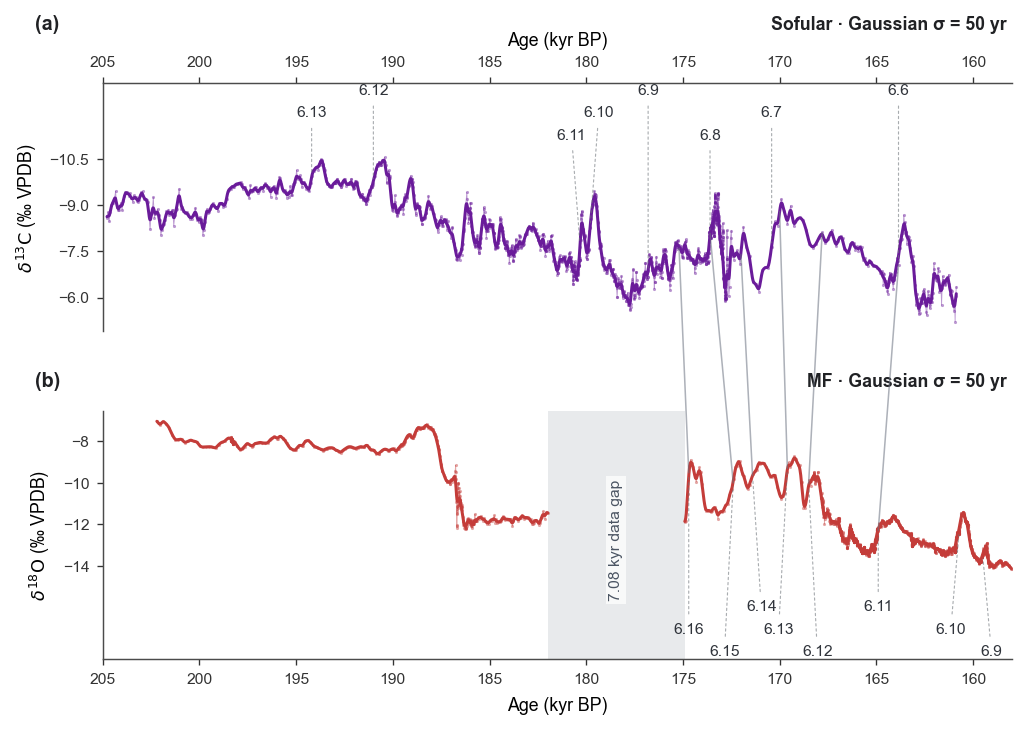

In [5]:
fig_comparison, axes = plt.subplots(2, 1, figsize=(180 / 25.4, 125 / 25.4), sharex=True,
                                    gridspec_kw=dict(left=0.13, right=0.985, top=0.89, bottom=0.11, hspace=0.32))
for letter, name, ax in zip("ab", ("Sofular", "MF"), axes):
    spec, frame = specs[name], records[name]
    local = record_anchors[name]
    local = local.loc[local.anchor_age_ka_bp.between(*comparison_range)].reset_index(drop=True)
    age, proxy = frame.age_ka_bp.to_numpy(), frame.proxy.to_numpy()
    style_axis(ax)
    ax.set_xlim(comparison_range[1], comparison_range[0])
    ax.xaxis.set_major_locator(MultipleLocator(5))
    draw_curves(ax, name, color=spec["color"], lw=0.4, marker="o", markersize=1.5, markeredgewidth=0, alpha=0.45)
    low, high = proxy.min(), proxy.max()
    span = high - low
    ax.set_ylim((high + 0.06 * span, low - 0.45 * span) if spec["invert"] else (low - 0.45 * span, high + 0.06 * span))
    ticks = MaxNLocator(nbins=5).tick_values(low, high)
    ax.set_yticks(ticks[(ticks >= low) & (ticks <= high)])
    ax.set_ylabel(spec["proxy"], labelpad=5)
    heading_y = 1.20 if letter == "a" else 1.08
    ax.text(-0.075, heading_y, f"({letter})", transform=ax.transAxes, ha="left", va="bottom",
            fontsize=9.5, fontweight="bold", color="#202124", clip_on=False, zorder=7)
    ax.text(0.995, heading_y, f'{name} · Gaussian σ = {spec["sigma"] * 1000:.0f} yr',
            transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5,
            fontweight="semibold", color="#202124", clip_on=False, zorder=7)
    levels = (0.97, 0.88, 0.79) if name == "Sofular" else (0.03, 0.12, 0.21)
    label_ages = spread_label_positions(local.anchor_age_ka_bp.to_numpy())
    for i, event in local.iterrows():
        x = event.anchor_age_ka_bp
        ax.annotate(event.display_label, xy=(x, np.interp(x, age, proxy)), xycoords="data",
                    xytext=(label_ages[i], levels[i % 3]), textcoords=ax.get_xaxis_transform(),
                    ha="center", va="center", fontsize=7.5, color="#30343B",
                    arrowprops=dict(arrowstyle="-", color="#6F757B", linewidth=0.55,
                                    linestyle=(0, (2, 2.5)), alpha=0.6), zorder=6)

for _, match in matches.iterrows():
    x_so, x_mf = match["Sofular"], match["MF"]
    y_so = np.interp(x_so, records["Sofular"].age_ka_bp, records["Sofular"].proxy)
    y_mf = np.interp(x_mf, records["MF"].age_ka_bp, records["MF"].proxy)
    fig_comparison.add_artist(ConnectionPatch(xyA=(x_so, y_so), coordsA=axes[0].transData,
                                               xyB=(x_mf, y_mf), coordsB=axes[1].transData,
                                               color="#6B7280", lw=0.75, alpha=0.55, clip_on=False, zorder=3))
age = records["MF"].age_ka_bp.to_numpy()
for i in np.flatnonzero(np.diff(age) > gap_threshold):
    start, end = age[i:i + 2]
    axes[1].axvspan(start, end, color="#6B7280", alpha=0.15, lw=0)
    axes[1].text((start + end) / 2, 0.48, f"{end - start:.2f} kyr data gap",
                 transform=axes[1].get_xaxis_transform(), rotation=90, ha="center", va="center",
                 fontsize=7.5, color="#4B5563",
                 bbox=dict(facecolor="white", edgecolor="none", alpha=0.72, pad=1.4), zorder=6)
axes[0].spines["bottom"].set_visible(False)
axes[0].spines["top"].set_visible(True)
axes[0].xaxis.set_ticks_position("top")
axes[0].xaxis.set_label_position("top")
axes[0].tick_params(axis="x", top=True, labeltop=True, bottom=False)
for ax in axes:
    ax.set_xlabel("Age (kyr BP)", labelpad=5)
plt.show()

## Save both figures

The overview is 180 × 230 mm and the focused comparison is 180 × 125 mm. Each is saved as a 600 dpi PNG and a vector PDF under `figures/Speleothem_published_event_plot/`, using the existing filenames. This cell overwrites those four figures; no input tables or event-age outputs are written.

In [6]:
figure_dir.mkdir(parents=True, exist_ok=True)
for stem, figure, title in (
    ("Speleothem_published_event_plot", fig_overview, "MIS 6 speleothem variability and local sampling resolution"),
    ("Sofular_MF_comparison", fig_comparison, "Sofular and MF MIS 6 speleothem comparison"),
):
    figure.savefig(figure_dir / f"{stem}.png", dpi=600)
    figure.savefig(figure_dir / f"{stem}.pdf", metadata={
        "Title": title, "Creator": "Speleothem_published_event_plot.ipynb",
    })
    copy_pdf_to_paper(figure_dir / f"{stem}.pdf")
sorted(path.name for path in figure_dir.iterdir() if path.suffix in (".png", ".pdf"))

['Sofular_MF_comparison.pdf',
 'Sofular_MF_comparison.png',
 'Speleothem_published_event_plot.pdf',
 'Speleothem_published_event_plot.png']